In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os


In [ ]:
test_img = "/content/0001.png"
test_image = np.array(Image.open(test_img))
path_img = "/content/0001.png"

In [ ]:
def psnr(img1, img2):
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf')
    max_pixel_value = 255.0
    psnr_value = 20 * np.log10(max_pixel_value / np.sqrt(mse))
    return psnr_value

## Білінійна інтерполяція

In [ ]:
def bilinear_interpolation(image, scale_factor):
    height, width, channels = image.shape
    new_height = int(height * scale_factor)
    new_width = int(width * scale_factor)

    new_image = np.zeros((new_height, new_width, channels), dtype=np.uint8)

    for i in range(new_height):
        for j in range(new_width):
            y = i / scale_factor
            x = j / scale_factor

            y1, y2 = int(np.floor(y)), int(np.ceil(y))
            x1, x2 = int(np.floor(x)), int(np.ceil(x))

            if x2 >= width:
                x2 = width - 1
            if y2 >= height:
                y2 = height - 1

            A = image[y1, x1]
            B = image[y1, x2]
            C = image[y2, x1]
            D = image[y2, x2]

            x_ratio = x - x1
            y_ratio = y - y1

            new_pixel = (1 - x_ratio) * (1 - y_ratio) * A + x_ratio * (1 - y_ratio) * B + (1 - x_ratio) * y_ratio * C + x_ratio * y_ratio * D

            new_image[i, j] = new_pixel.astype(np.uint8)

    return new_image

In [ ]:
image_path = path_img
original_image = np.array(Image.open(image_path))

In [ ]:
scaled_image = Image.fromarray(bilinear_interpolation(np.array(original_image), 4.0))

In [ ]:
plt.figure(figsize=(40, 20))

plt.subplot(1, 3, 1)
plt.imshow(original_image)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(scaled_image)
plt.title('Bilinear Interpolation')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(test_image)
plt.title(f'Orig ')
plt.axis('off')

In [ ]:
scaled_image_path = os.path.join('/content/drive/MyDrive/Data2/Bilineal_result', os.path.basename(image_path).split('.')[0] + '.png')

In [ ]:
scaled_image.save(scaled_image_path)

In [ ]:
image1 = np.array(Image.open('/content/drive/MyDrive/Data2/Bilineal_result/babyе.png').resize(test_image.shape[1::-1])).astype(np.float32)
image2 = test_image.astype(np.float32)

In [ ]:
psnr_value = psnr(image1, image2)
print(f"PSNR: {psnr_value} dB")

## K найближчих сусідів

In [ ]:
import numpy as np
from scipy.spatial.distance import cdist
from PIL import Image

In [ ]:
def knn_interpolation(image, scale_factor, k):
    height, width, channels = image.shape
    new_height = int(height * scale_factor)
    new_width = int(width * scale_factor)

    new_image = np.zeros((new_height, new_width, channels), dtype=np.uint8)

    for i in range(new_height):
        for j in range(new_width):
            y = i / scale_factor
            x = j / scale_factor

            y1, y2 = int(np.floor(y)), int(np.ceil(y))
            x1, x2 = int(np.floor(x)), int(np.ceil(x))

            if x2 >= width:
                x2 = width - 1
            if y2 >= height:
                y2 = height - 1

            neighbors_coords = np.array([[y1, x1], [y1, x2], [y2, x1], [y2, x2]])
            distances = cdist([[y, x]], neighbors_coords, 'euclidean')[0]

            sorted_indices = np.argsort(distances)[:k]

            neighbor_values = image[neighbors_coords[sorted_indices, 0], neighbors_coords[sorted_indices, 1]]

            new_pixel = np.mean(neighbor_values, axis=0)

            new_image[i, j] = new_pixel.astype(np.uint8)

    return new_image

image_path = path_img
original_image = np.array(Image.open(image_path))

In [ ]:
scale_factor = 4.0
k_neighbors = 4

In [ ]:
scaled_image = Image.fromarray(knn_interpolation(original_image, scale_factor, k_neighbors))

KeyboardInterrupt: 

(-0.5, 2039.5, 1403.5, -0.5)

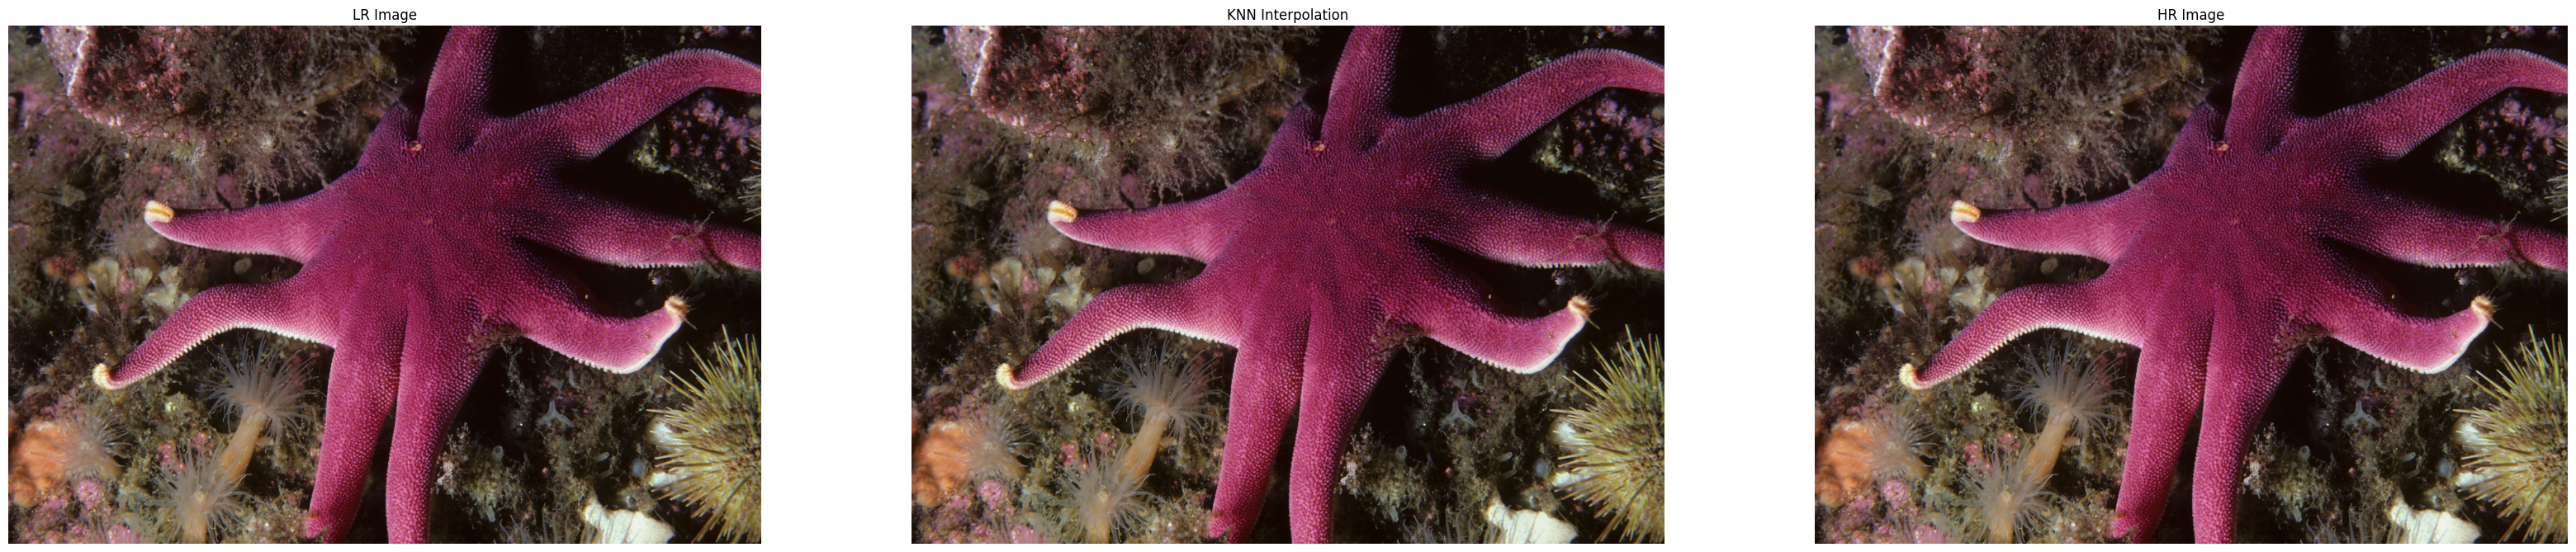

In [ ]:
plt.figure(figsize=(40, 20))

plt.subplot(1, 3, 1)
plt.imshow(original_image)
plt.title('LR Image')
plt.axis('off')  # Скрыть оси

plt.subplot(1, 3, 2)
plt.imshow(scaled_image)
plt.title('KNN Interpolation')
plt.axis('off')  # Скрыть оси

plt.subplot(1, 3, 3)
plt.imshow(test_image)
plt.title(f'HR Image')
plt.axis('off')  # Скрыть оси


In [ ]:
scaled_image_path = os.path.join('/content/drive/MyDrive/Data2/K-near_result', os.path.basename(image_path).split('.')[0] + '.png')

In [ ]:
scaled_image.save(scaled_image_path)

In [ ]:
image1 = np.array(Image.open('/content/drive/MyDrive/Data2/K-near_result/85048.png').resize(test_image.shape[1::-1])).astype(np.float32)
image2 = test_image.astype(np.float32)

In [ ]:
psnr_value = psnr(image1, image2)
print(f"PSNR: {psnr_value} dB")

## Бікубічна інтерполяція

In [ ]:
from skimage import io, transform

image = io.imread(path_img)
scale_factor = 4.0
scaled_image = transform.resize(image, (image.shape[0] * scale_factor, image.shape[1] * scale_factor))
scaled_image = (scaled_image * 255).astype('uint8')

In [ ]:
scaled_image = Image.fromarray(scaled_image)

In [ ]:
plt.figure(figsize=(40, 20))

plt.subplot(1, 3, 1)
plt.imshow(original_image)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(scaled_image)
plt.title('Bicube')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(test_image)
plt.title(f'Orig (K={k_neighbors})')
plt.axis('off')

In [ ]:
scaled_image_path = os.path.join('/content/drive/MyDrive/Data2/BiCube', os.path.basename(path_img).split('.')[0] + '.png')
scaled_image.save(scaled_image_path)

In [ ]:
image1 = np.array(Image.open('/content/drive/MyDrive/Data2/BiCube/babyе.png').resize(test_image.shape[1::-1])).astype(np.float32)
image2 = test_image.astype(np.float32)

In [ ]:
psnr_value = psnr(image1, image2)
print(f"PSNR: {psnr_value} dB")

## Super-resolution

In [ ]:
import math

from IPython.display import display

import numpy as np

import os

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.preprocessing.image import array_to_img
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.optimizers import Adam

import pathlib

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
from PIL import Image

In [ ]:
crop_x, crop_y = 240, 160
batch_size = 8

train_data = image_dataset_from_directory(
    '/content/drive/MyDrive/Data2/Train',
    batch_size=batch_size,
    image_size=(crop_y, crop_x),
    validation_split=0.2,
    subset="training",
    seed=123,
    label_mode=None,
)

validation_data = image_dataset_from_directory(
    '/content/drive/MyDrive/Data2/Train',
    batch_size=batch_size,
    image_size=(crop_y, crop_x),
    validation_split=0.2,
    subset="validation",
    seed=123,
    label_mode=None,
)

Found 100 files belonging to 1 classes.
Using 80 files for training.
Found 100 files belonging to 1 classes.
Using 20 files for validation.


In [ ]:
crop_x, crop_y = 120, 80
batch_size = 8

test_data = image_dataset_from_directory(
    '/content/drive/MyDrive/Data2/Test',
    batch_size=batch_size,
    image_size=(crop_y, crop_x),
    validation_split=0.2,
    subset="training",
    seed=123,
    label_mode=None,
)

validation_test = image_dataset_from_directory(
    '/content/drive/MyDrive/Data2/Test',
    batch_size=batch_size,
    image_size=(crop_y, crop_x),
    validation_split=0.2,
    subset="validation",
    seed=123,
    label_mode=None,
)


Found 100 files belonging to 1 classes.
Using 80 files for training.
Found 100 files belonging to 1 classes.
Using 20 files for validation.


In [ ]:
def normalize(image):
    return image / 255

train_data = train_data.map(normalize)
validation_data = validation_data.map(normalize)

In [ ]:
test_data = test_data.map(normalize)
validation_test = validation_test.map(normalize)

In [ ]:
def grayscale(input):
    input = tf.image.rgb_to_yuv(input)
    last_dimension_axis = len(input.shape) - 1
    y, u, v = tf.split(input, 3, axis=last_dimension_axis)
    return y

In [ ]:
combined_data = tf.data.Dataset.zip((test_data, train_data))

In [ ]:
combined_data

<_ZipDataset element_spec=(TensorSpec(shape=(None, 80, 120, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 160, 240, 3), dtype=tf.float32, name=None))>

In [ ]:
train_data = combined_data.map(
     lambda x,y: (grayscale(x), grayscale(y))
)

In [ ]:
combined_val = tf.data.Dataset.zip((validation_test, validation_data))

In [ ]:
validation_data = combined_val.map(
     lambda x,y: (grayscale(x), grayscale(y))
)

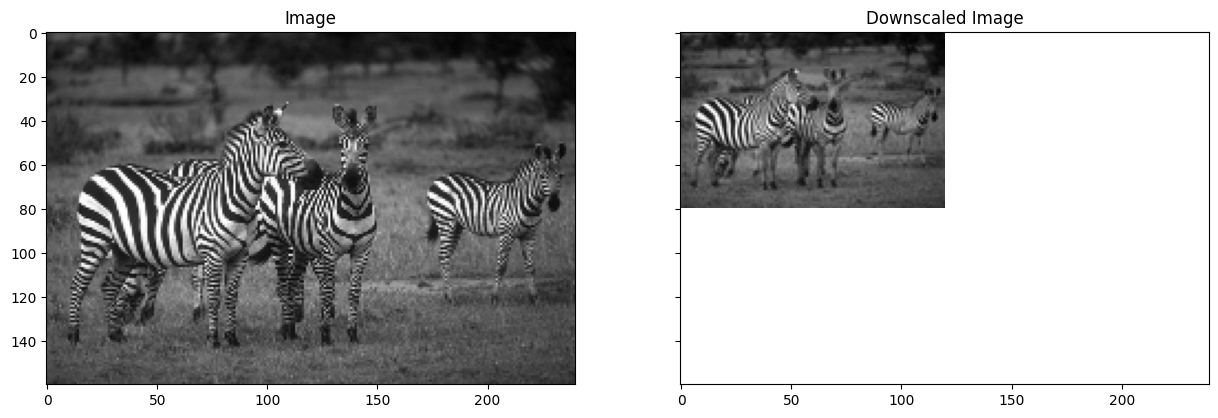

In [ ]:
import matplotlib.pyplot as plt

for batch in train_data.take(1):
    fig, (a0, a1) = plt.subplots(1,2, figsize=(15, 7), sharex=True, sharey=True)

    greyscaled = batch[1][0]
    greyscaled = array_to_img(greyscaled)

    downscaled = batch[0][0]
    downscaled = array_to_img(downscaled)

    a1.imshow(downscaled, cmap='gray')
    a1.set_title("Downscaled Image")

    a0.imshow(greyscaled, cmap='gray')
    a0.set_title("Image")


    plt.show()

In [ ]:
def create_model(img_channels=1, upscale_factor=2):
  inputs = Input(shape=(None, None, img_channels))
  x = layers.Conv2D(64, 5, activation="tanh", padding="same")(inputs)
  x = layers.ReLU()(x)
  x = layers.Conv2D(32, 3,  activation="tanh", padding="same")(x)
  x = layers.ReLU()(x)
  x = layers.Conv2D(img_channels*(upscale_factor ** 2), 3,  activation="tanh", padding="same")(x)
  outputs = tf.nn.depth_to_space(x, upscale_factor)
  return Model(inputs, outputs)

model = create_model()
model.summary()

epochs = 100
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=MeanSquaredError(),
)
model.fit(
    train_data, epochs=epochs, callbacks=[EarlyStopping(monitor="loss", patience=10)], validation_data=validation_data, verbose=1
)

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, None, None, 1)]   0         
                                                                 
 conv2d_3 (Conv2D)           (None, None, None, 64)    1664      
                                                                 
 re_lu_2 (ReLU)              (None, None, None, 64)    0         
                                                                 
 conv2d_4 (Conv2D)           (None, None, None, 32)    18464     
                                                                 
 re_lu_3 (ReLU)              (None, None, None, 32)    0         
                                                                 
 conv2d_5 (Conv2D)           (None, None, None, 4)     1156      
                                                                 
 tf.nn.depth_to_space_1 (TF  (None, None, None, 1)     0   

In [ ]:
import PIL

In [ ]:
def load_image(path, downfactor=3):
	original_img = load_img(path)
	downscaled = original_img.resize((original_img.size[0] // downfactor,
		original_img.size[1] // downfactor), Image.BICUBIC)
	return (original_img, downscaled)

def get_y_channel(image):
	ycbcr = image.convert("YCbCr")
	(y, cb, cr) = ycbcr.split()
	y = np.array(y)
	y = normalize(y.astype("float32"))
	return (y, cb, cr)

def upscale_image(img, model):
    y, cb, cr = get_y_channel(img)
    input = np.expand_dims(y, axis=0)
    out = model.predict(input)[0]
    out *= 255.0
    out = out.clip(0, 255)
    out = out.reshape((np.shape(out)[0], np.shape(out)[1]))
    new_y = Image.fromarray(np.uint8(out), mode="L")
    new_cb = cb.resize(new_y.size, PIL.Image.BICUBIC)
    new_cr = cr.resize(new_y.size, PIL.Image.BICUBIC)
    res = PIL.Image.merge("YCbCr", (new_y, new_cb, new_cr)).convert(
        "RGB"
    )
    return res


In [ ]:
from tensorflow.keras.models import load_model

# Предположим, что ваша модель уже обучена и названа model
# Сохранение модели в файл
model.save('resolution2x.h5')

In [ ]:
test_path = os.path.join(path_img)
original_img = load_img(test_path)
scaled_image = upscale_image(original_img, model)

1/1 [==============================] - 0s 264ms/step


(-0.5, 509.5, 350.5, -0.5)

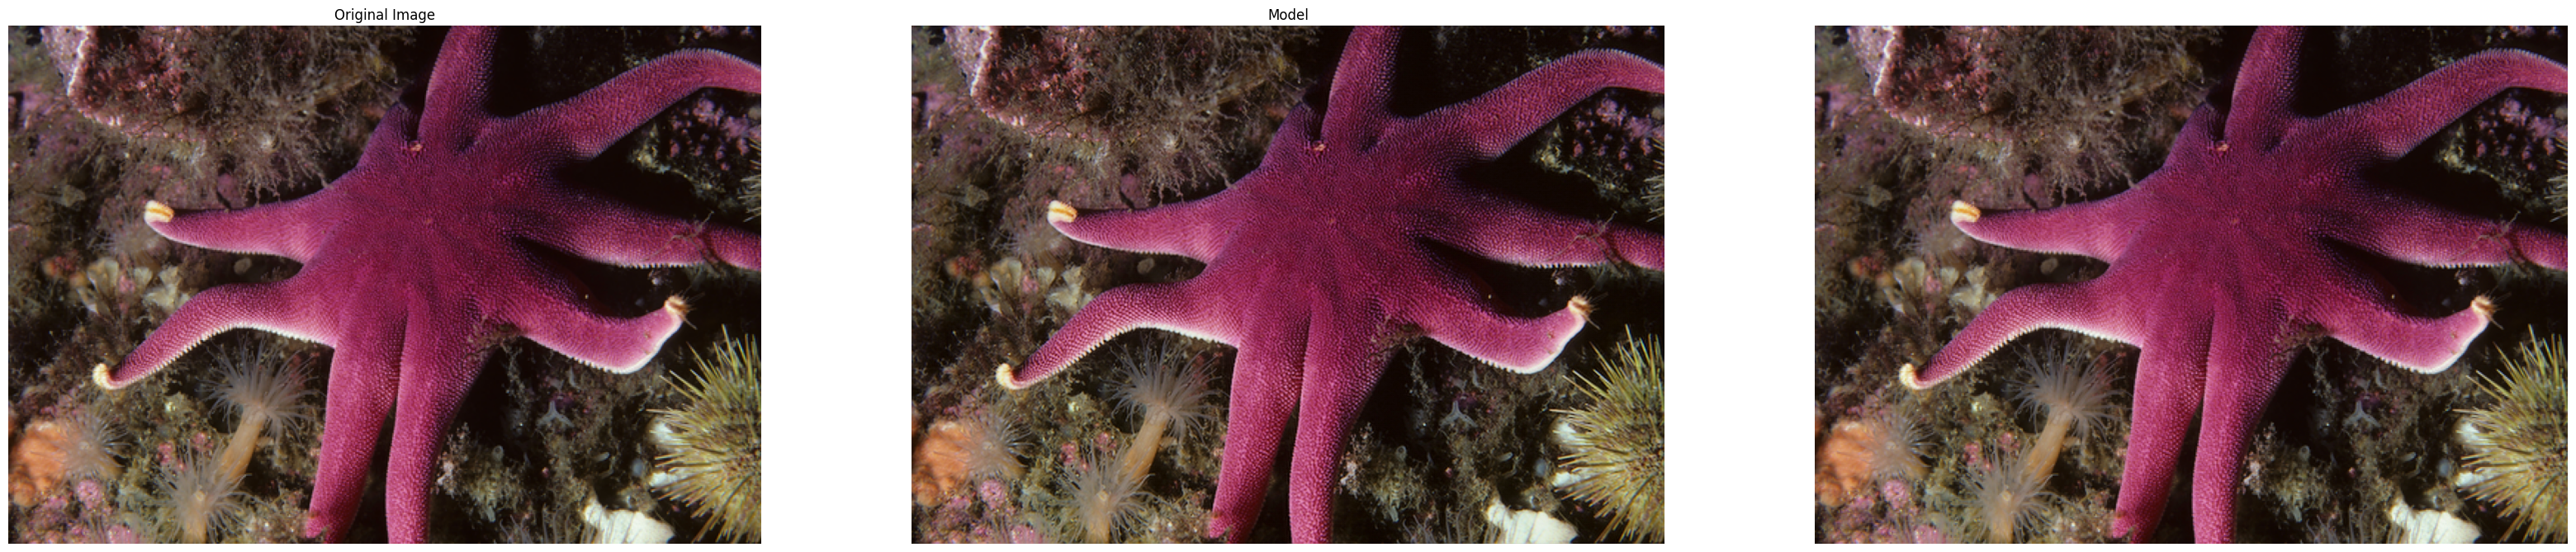

In [ ]:
plt.figure(figsize=(40, 20))

plt.subplot(1, 3, 1)
plt.imshow(original_img)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(scaled_image)
plt.title('Model')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(test_image)
#plt.title(f'Orig (K={k_neighbors})')
plt.axis('off')

In [ ]:
scaled_image_path = os.path.join('/content/drive/MyDrive/Data2/Model', os.path.basename(test_path).split('.')[0] + '.png')
scaled_image.save(scaled_image_path)

In [ ]:
image1 = np.array(Image.open('/content/drive/MyDrive/Data2/Model/babyе.png').resize(test_image.shape[1::-1])).astype(np.float32)
image2 = test_image.astype(np.float32)

In [ ]:
psnr_value = psnr(image1, image2)
print(f"PSNR: {psnr_value} dB")